<a href="https://colab.research.google.com/github/hgkim-gnbeng/tunnel_fire_dynamics_book/blob/main/%ED%8F%B4%EB%A6%AC%ED%8A%B8%EB%A1%9C%ED%94%BD_%EC%84%A0%EB%8F%84%EC%9E%91%EC%84%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

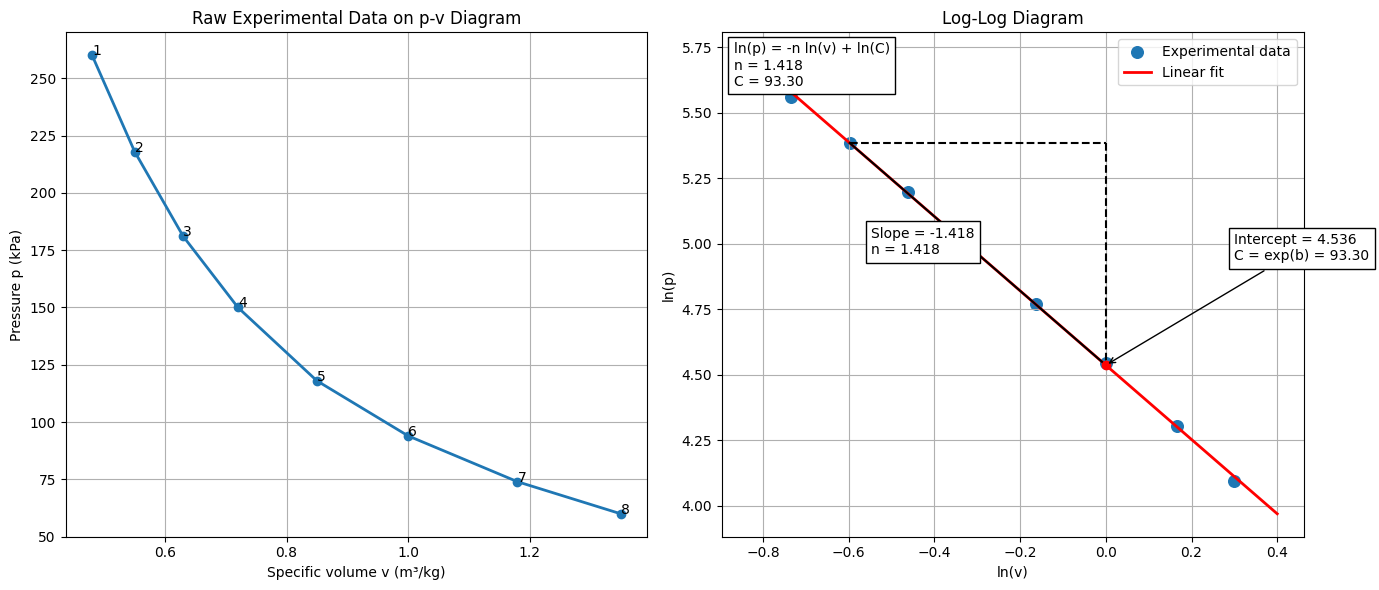

===== Regression Result =====
Slope m     = -1.41823
Intercept b = 4.53582
n = 1.41823
C = 93.30025

Estimated relation:
p * v^1.418 = 93.300


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 실험 데이터
# ============================================================

p = np.array([260, 218, 181, 150, 118, 94, 74, 60])   # kPa
v = np.array([0.48, 0.55, 0.63, 0.72, 0.85, 1.00, 1.18, 1.35])  # m3/kg

# ============================================================
# 로그 변환
# ============================================================

ln_p = np.log(p)
ln_v = np.log(v)

# ============================================================
# 선형 회귀
# ============================================================

m, b = np.polyfit(ln_v, ln_p, 1)

n = -m
C = np.exp(b)

# ============================================================
# 회귀선 생성
# ============================================================

x_fit = np.linspace(ln_v.min()-0.1, ln_v.max()+0.1, 200)
y_fit = m*x_fit + b

# ============================================================
# Figure 생성
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ============================================================
# (1) p-v 선도
# ============================================================

axes[0].plot(v, p, 'o-', linewidth=2)

axes[0].set_xlabel("Specific volume v (m³/kg)")
axes[0].set_ylabel("Pressure p (kPa)")
axes[0].set_title("Raw Experimental Data on p-v Diagram")

axes[0].grid(True)

# 데이터 번호 표시
for i in range(len(v)):
    axes[0].text(v[i], p[i], f"{i+1}")

# ============================================================
# (2) 로그-로그 선도
# ============================================================

axes[1].scatter(ln_v, ln_p, s=70, label="Experimental data")

axes[1].plot(x_fit, y_fit, 'r-', linewidth=2,
             label=f"Linear fit")

# 기울기 삼각형 표시
x1 = ln_v[1]
x2 = ln_v[5]

y1 = m*x1 + b
y2 = m*x2 + b

axes[1].plot([x1, x2], [y1, y1], 'k--')
axes[1].plot([x2, x2], [y1, y2], 'k--')
axes[1].plot([x1, x2], [y1, y2], 'k-')

axes[1].text(
    x1+0.05,
    (y1+y2)/2,
    f"Slope = {m:.3f}\n"
    f"n = {-m:.3f}",
    fontsize=10,
    bbox=dict(facecolor='white')
)

# 절편 표시
axes[1].plot(0, b, 'ro')

axes[1].annotate(
    f"Intercept = {b:.3f}\nC = exp(b) = {C:.2f}",
    xy=(0, b),
    xytext=(0.3, b+0.4),
    arrowprops=dict(arrowstyle='->'),
    bbox=dict(facecolor='white')
)

# 정보 표시
info = (
    f"ln(p) = -n ln(v) + ln(C)\n"
    f"n = {n:.3f}\n"
    f"C = {C:.2f}"
)

axes[1].text(
    0.02,
    0.98,
    info,
    transform=axes[1].transAxes,
    va='top',
    bbox=dict(facecolor='white')
)

axes[1].set_xlabel("ln(v)")
axes[1].set_ylabel("ln(p)")
axes[1].set_title("Log-Log Diagram")

axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

# ============================================================
# 결과 출력
# ============================================================

print("===== Regression Result =====")
print(f"Slope m     = {m:.5f}")
print(f"Intercept b = {b:.5f}")

print(f"n = {-m:.5f}")
print(f"C = {C:.5f}")

print()
print(f"Estimated relation:")
print(f"p * v^{n:.3f} = {C:.3f}")